In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# paths
OHIO_PATH = os.path.expanduser('~/Desktop/diabloom/data/raw/ohiot1dm')
MODEL_SAVE_PATH = os.path.expanduser('~/Desktop/diabloom/models/glucose_lstm_ohio_final.pt')

# constants
GLUCOSE_MIN, GLUCOSE_MAX = 40, 400
HYPO_THRESHOLD = 70
WINDOW_SIZE = 24
HORIZON = 6
IOB_MAX = 20.0

FEATURE_COLS = ['glucose_norm', 'delta_1', 'delta_3', 'delta_6',
                'rolling_mean_12', 'rolling_std_12',
                'hour_sin', 'hour_cos', 'iob_norm']

PATIENT_IDS = ['559', '563', '570', '575', '588', '591']

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Patients: {PATIENT_IDS}")
print(f"Features: {len(FEATURE_COLS)}")

Device: mps
Patients: ['559', '563', '570', '575', '588', '591']
Features: 9


In [4]:
def parse_ohio_glucose(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for entry in root.find('glucose_level'):
        records.append({
            'timestamp': pd.to_datetime(
                entry.attrib['ts'], format='%d-%m-%Y %H:%M:%S'
            ),
            'glucose_mgdl': float(entry.attrib['value'])
        })
    df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    return df

def parse_ohio_bolus(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for entry in root.find('bolus'):
        records.append({
            'timestamp': pd.to_datetime(
                entry.attrib['ts_begin'], format='%d-%m-%Y %H:%M:%S'
            ),
            'dose': float(entry.attrib['dose'])
        })
    df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    return df

def compute_iob(glucose_df, bolus_df, 
                peak_mins=60, duration_mins=240):
    boluses = bolus_df[bolus_df['dose'] > 0].copy()
    glucose_df = glucose_df.copy()
    iob_values = []
    for t in glucose_df['timestamp']:
        total_iob = 0.0
        for _, bolus in boluses.iterrows():
            mins_elapsed = (t - bolus['timestamp']).total_seconds() / 60
            if 0 <= mins_elapsed <= duration_mins:
                remaining = max(0, 1 - (mins_elapsed / duration_mins))
                total_iob += bolus['dose'] * remaining
        iob_values.append(total_iob)
    glucose_df['iob'] = iob_values
    return glucose_df

# load all patients
print("Loading patients...")
ohio_data = {}
for fname in sorted(os.listdir(OHIO_PATH)):
    if 'training' in fname and fname.endswith('.xml'):
        pid = fname.split('-')[0]
        fpath = os.path.join(OHIO_PATH, fname)
        glucose = parse_ohio_glucose(fpath)
        bolus = parse_ohio_bolus(fpath)
        ohio_data[pid] = {'glucose': glucose, 'bolus': bolus}
        print(f"Patient {pid}: {len(glucose)} glucose readings, "
              f"{len(bolus)} bolus records")

print(f"\nLoaded {len(ohio_data)} patients")

Loading patients...
Patient 559: 10796 glucose readings, 152 bolus records
Patient 563: 12124 glucose readings, 347 bolus records
Patient 570: 10982 glucose readings, 326 bolus records
Patient 575: 11866 glucose readings, 187 bolus records
Patient 588: 12640 glucose readings, 182 bolus records
Patient 591: 10847 glucose readings, 261 bolus records

Loaded 6 patients


In [5]:
# compute IOB for all patients
print("Computing IOB (this will take a few minutes)...")
ohio_iob_data = {}

for pid, data in ohio_data.items():
    glucose_df = data['glucose'].copy()
    bolus_df = data['bolus'].copy()
    
    glucose_with_iob = compute_iob(glucose_df, bolus_df)
    ohio_iob_data[pid] = glucose_with_iob
    
    nonzero = (glucose_with_iob['iob'] > 0).sum()
    pct = 100 * nonzero / len(glucose_with_iob)
    print(f"Patient {pid}: IOB non-zero: {nonzero}/{len(glucose_with_iob)} "
          f"({pct:.1f}%) | max IOB: {glucose_with_iob['iob'].max():.2f}U")

print("\nIOB computation complete")

Computing IOB (this will take a few minutes)...
Patient 559: IOB non-zero: 5727/10796 (53.0%) | max IOB: 12.59U
Patient 563: IOB non-zero: 8998/12124 (74.2%) | max IOB: 48.22U
Patient 570: IOB non-zero: 7110/10982 (64.7%) | max IOB: 26.69U
Patient 575: IOB non-zero: 6975/11866 (58.8%) | max IOB: 16.40U
Patient 588: IOB non-zero: 7333/12640 (58.0%) | max IOB: 9.93U
Patient 591: IOB non-zero: 7745/10847 (71.4%) | max IOB: 10.34U

IOB computation complete


In [6]:
# D1NAMO normalisation stats (computed earlier, hardcoded here)
# these ensure OhioT1DM features are on the same scale as D1NAMO training
NORM_STATS = {
    'delta_1':        {'mean': 0.0281,  'std': 5.6046},
    'delta_3':        {'mean': 0.0985,  'std': 15.2474},
    'delta_6':        {'mean': 0.2321,  'std': 28.2503},
    'rolling_mean_12':{'mean': 166.1347,'std': 74.5364},
    'rolling_std_12': {'mean': 12.0754, 'std': 11.2882}
}

def engineer_features(glucose_iob_df):
    df = glucose_iob_df.copy().sort_values('timestamp').reset_index(drop=True)
    
    df['glucose_norm'] = (df['glucose_mgdl'] - GLUCOSE_MIN) / (GLUCOSE_MAX - GLUCOSE_MIN)
    df['delta_1'] = df['glucose_mgdl'].diff(1)
    df['delta_3'] = df['glucose_mgdl'].diff(3)
    df['delta_6'] = df['glucose_mgdl'].diff(6)
    df['rolling_mean_12'] = df['glucose_mgdl'].rolling(12).mean()
    df['rolling_std_12'] = df['glucose_mgdl'].rolling(12).std()
    df['hour_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24)
    df['iob_norm'] = np.clip(df['iob'] / IOB_MAX, 0, 1)
    
    # normalise delta and rolling features using D1NAMO stats
    for col in ['delta_1', 'delta_3', 'delta_6',
                'rolling_mean_12', 'rolling_std_12']:
        mean = NORM_STATS[col]['mean']
        std = NORM_STATS[col]['std']
        df[col] = (df[col] - mean) / (std + 1e-8)
    
    df = df.dropna().reset_index(drop=True)
    return df

def create_windows(df, feature_cols, 
                   window_size=WINDOW_SIZE, horizon=HORIZON):
    data = df[feature_cols].values
    target = df['glucose_norm'].values
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i + window_size])
        y.append(target[i + window_size + horizon])
    return np.array(X), np.array(y)

# build windows with 80/20 temporal split
X_train_all, y_train_all = [], []
X_val_all, y_val_all = [], []

for pid, glucose_iob_df in ohio_iob_data.items():
    features_df = engineer_features(glucose_iob_df)
    
    split = int(len(features_df) * 0.8)
    train_df = features_df.iloc[:split]
    val_df = features_df.iloc[split:]
    
    X_tr, y_tr = create_windows(train_df, FEATURE_COLS)
    X_val, y_val = create_windows(val_df, FEATURE_COLS)
    
    if X_tr.shape[0] > 0:
        X_train_all.append(X_tr)
        y_train_all.append(y_tr)
    if X_val.shape[0] > 0:
        X_val_all.append(X_val)
        y_val_all.append(y_val)
    
    print(f"Patient {pid}: train {X_tr.shape[0]}, val {X_val.shape[0]}")

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_val = np.concatenate(X_val_all)
y_val = np.concatenate(y_val_all)

print(f"\nFinal training set: {X_train.shape}")
print(f"Final validation set: {X_val.shape}")
print(f"Feature dimension: {X_train.shape[2]} (should be 9)")

Patient 559: train 8598, val 2127
Patient 563: train 9660, val 2393
Patient 570: train 8746, val 2165
Patient 575: train 9454, val 2341
Patient 588: train 10073, val 2496
Patient 591: train 8638, val 2138

Final training set: (55169, 24, 9)
Final validation set: (13660, 24, 9)
Feature dimension: 9 (should be 9)


In [7]:
class GlucoseLSTM(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, 
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze()

# tensors
X_tr = torch.FloatTensor(X_train)
y_tr = torch.FloatTensor(y_train)
X_v = torch.FloatTensor(X_val)
y_v = torch.FloatTensor(y_val)

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                         batch_size=32, shuffle=True)

# training setup
model = GlucoseLSTM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training on: {device}")
print(f"Training samples: {len(X_tr)}")
print("Starting training...\n")

best_val_loss = float('inf')
best_epoch = 0
train_history = []
val_history = []

for epoch in range(50):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_v.to(device))
        val_loss = criterion(val_pred, y_v.to(device)).item()
    
    train_loss = np.mean(train_losses)
    train_history.append(train_loss)
    val_history.append(val_loss)
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train: {train_loss:.4f} "
              f"| val: {val_loss:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model parameters: 54,593
Training on: mps
Training samples: 55169
Starting training...



/Users/tavle/Desktop/diabloom/venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch   0 | train: 0.0070 | val: 0.0203
Epoch  10 | train: 0.0037 | val: 0.0072
Epoch  20 | train: 0.0024 | val: 0.0075
Epoch  30 | train: 0.0019 | val: 0.0082
Epoch  40 | train: 0.0018 | val: 0.0082

Best val loss: 0.0069 at epoch 9
Model saved to: /Users/tavle/Desktop/diabloom/models/glucose_lstm_ohio_final.pt


In [8]:
# load best checkpoint and evaluate
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

with torch.no_grad():
    val_pred = model(X_v.to(device)).cpu().numpy()

y_val_mgdl = y_val * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
val_pred_mgdl = val_pred * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

mae = np.mean(np.abs(val_pred_mgdl - y_val_mgdl))
rmse = np.sqrt(np.mean((val_pred_mgdl - y_val_mgdl) ** 2))
direction_acc = np.mean(
    (y_val_mgdl < HYPO_THRESHOLD) == (val_pred_mgdl < HYPO_THRESHOLD)
) * 100

print(f"=== DiabLoom v3 — OhioT1DM + IOB (Final Model) ===")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"Hypo direction accuracy: {direction_acc:.1f}%")

print(f"\n=== Per patient breakdown ===")
start = 0
for pid, glucose_iob_df in ohio_iob_data.items():
    features_df = engineer_features(glucose_iob_df)
    n_val = int(len(features_df) * 0.2) - WINDOW_SIZE - HORIZON
    if n_val > 0:
        p_mae = np.mean(np.abs(
            val_pred_mgdl[start:start+n_val] - 
            y_val_mgdl[start:start+n_val]
        ))
        print(f"  Patient {pid}: MAE {p_mae:.2f} mg/dL")
        start += n_val

print(f"\n=== Full comparison ===")
print(f"DiabLoom D1NAMO 8 features:          18.50 mg/dL")
print(f"DiabLoom OhioT1DM no IOB:            22.96 mg/dL")
print(f"DiabLoom OhioT1DM + IOB (final):     {mae:.2f} mg/dL")
print(f"Vanilla LSTM benchmark:              19.40 mg/dL")
print(f"DCRNet benchmark:                    14.13 mg/dL")

=== DiabLoom v3 — OhioT1DM + IOB (Final Model) ===
MAE:  21.27 mg/dL
RMSE: 30.01 mg/dL
Hypo direction accuracy: 97.5%

=== Per patient breakdown ===
  Patient 559: MAE 23.55 mg/dL
  Patient 563: MAE 17.91 mg/dL
  Patient 570: MAE 22.34 mg/dL
  Patient 575: MAE 22.86 mg/dL
  Patient 588: MAE 17.11 mg/dL
  Patient 591: MAE 24.62 mg/dL

=== Full comparison ===
DiabLoom D1NAMO 8 features:          18.50 mg/dL
DiabLoom OhioT1DM no IOB:            22.96 mg/dL
DiabLoom OhioT1DM + IOB (final):     21.27 mg/dL
Vanilla LSTM benchmark:              19.40 mg/dL
DCRNet benchmark:                    14.13 mg/dL


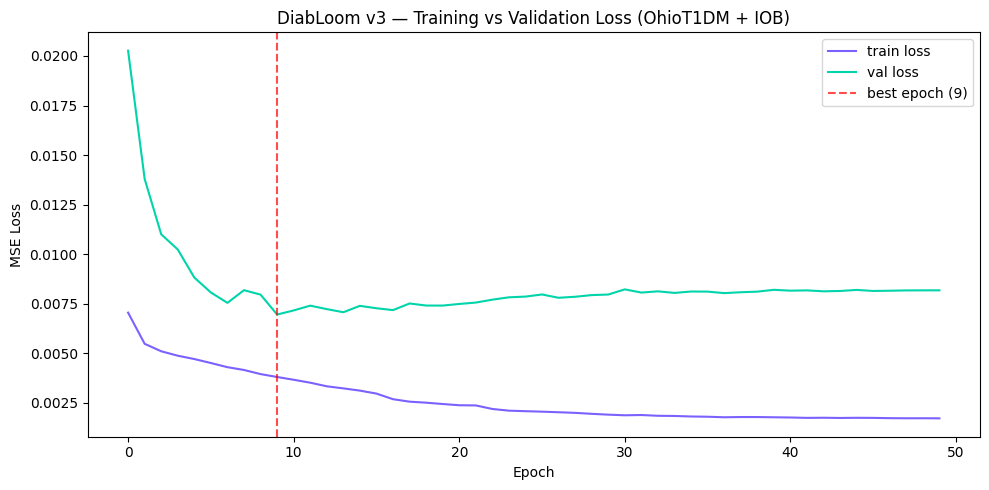

Loss curve saved


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label='train loss', color='#7B61FF')
plt.plot(val_history, label='val loss', color='#00D4AA')
plt.axvline(x=best_epoch, color='red', linestyle='--', 
            alpha=0.7, label=f'best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DiabLoom v3 — Training vs Validation Loss (OhioT1DM + IOB)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.expanduser(
    '~/Desktop/diabloom/results/loss_curve_ohio.png'), 
    dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved")

Running SHAP KernelExplainer (this will take a few minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 216)

=== Feature Importance (OhioT1DM + IOB) ===
  rolling_mean_12     : 0.0013 
  delta_1             : 0.0011 
  delta_3             : 0.0004 
  iob_norm            : 0.0003 
  rolling_std_12      : 0.0003 
  delta_6             : 0.0003 
  hour_cos            : 0.0003 
  glucose_norm        : 0.0003 
  hour_sin            : 0.0003 


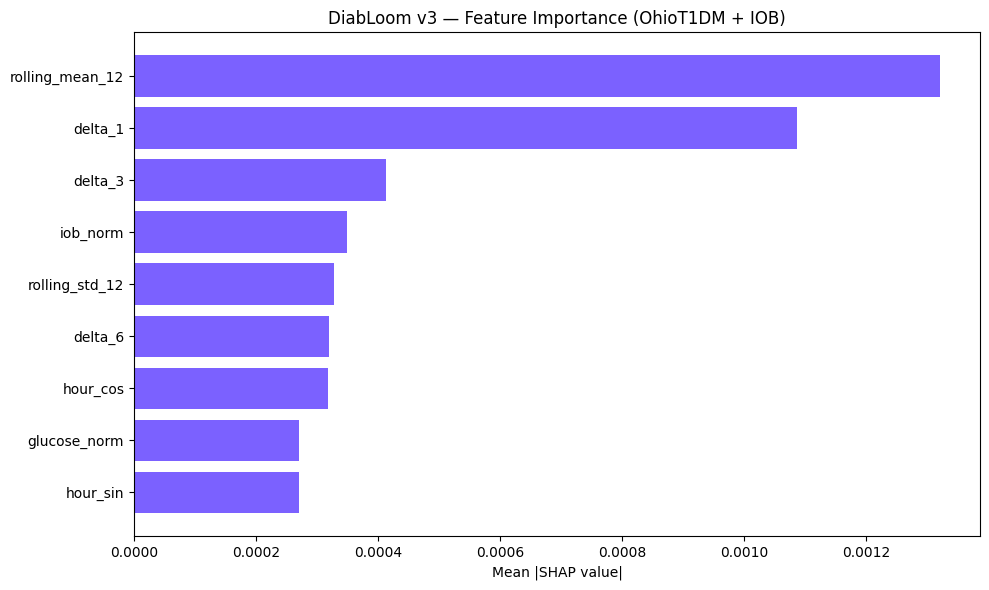


SHAP plot saved


In [11]:
import shap

# load model in eval mode
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

# wrapper function for SHAP — flattens (24,9) to (216,)
def model_predict(x_flat):
    x_tensor = torch.FloatTensor(
        x_flat.reshape(-1, WINDOW_SIZE, len(FEATURE_COLS))
    )
    x_tensor = x_tensor.to(device)
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()
    return preds.reshape(-1)  # ensure always 1D


# use small background sample for efficiency
np.random.seed(42)
background_idx = np.random.choice(len(X_train), 100, replace=False)
background = X_train[background_idx].reshape(100, -1)  # (100, 216)

# sample to explain
explain_idx = np.random.choice(len(X_val), 50, replace=False)
X_explain = X_val[explain_idx].reshape(50, -1)  # (50, 216)

# re-initialise explainer with fixed function
print("Running SHAP KernelExplainer (this will take a few minutes)...")
explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

print(f"SHAP values shape: {shap_values.shape}")

# reshape and compute importance
shap_reshaped = shap_values.reshape(50, WINDOW_SIZE, len(FEATURE_COLS))
feature_importance = np.abs(shap_reshaped).mean(axis=(0, 1))

print(f"\n=== Feature Importance (OhioT1DM + IOB) ===")
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 500)
    print(f"  {row['feature']:20s}: {row['importance']:.4f} {bar}")

# plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1],
         importance_df['importance'][::-1],
         color='#7B61FF')
plt.xlabel('Mean |SHAP value|')
plt.title('DiabLoom v3 — Feature Importance (OhioT1DM + IOB)')
plt.tight_layout()
plt.savefig(os.path.expanduser(
    '~/Desktop/diabloom/results/shap_ohio.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("\nSHAP plot saved")


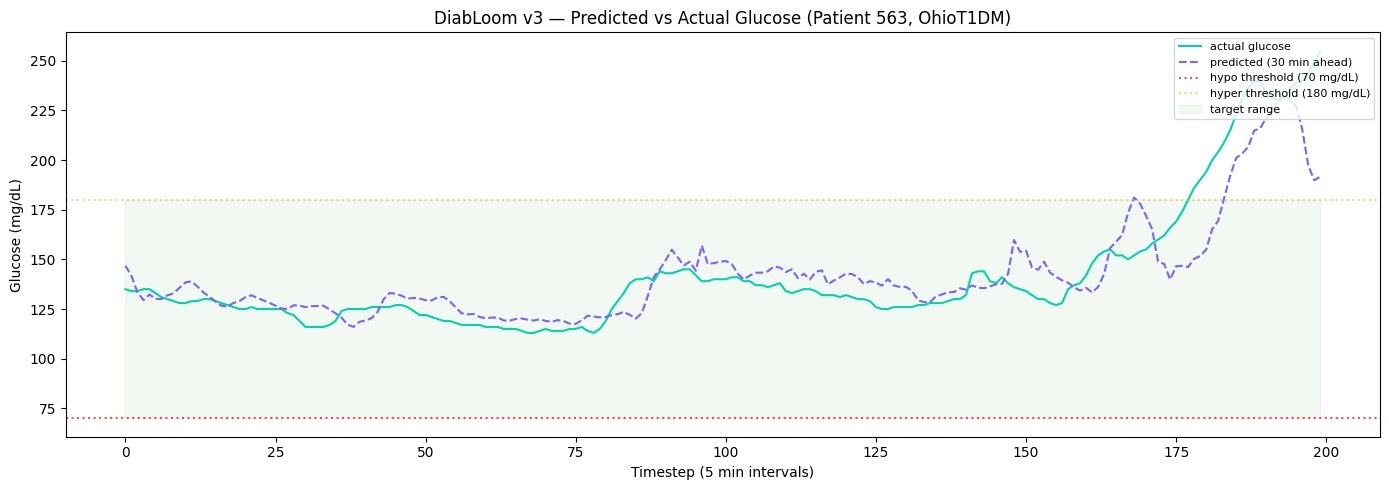

Patient 563 segment MAE: 9.98 mg/dL
Plot saved


In [12]:
# pick a continuous stretch from validation set for clean visualization
# use patient 563 (best MAE 17.91) for most impressive plot

# get patient 563 val data
patient_563_features = engineer_features(ohio_iob_data['563'])
split_563 = int(len(patient_563_features) * 0.8)
val_563 = patient_563_features.iloc[split_563:].reset_index(drop=True)
X_563, y_563 = create_windows(val_563, FEATURE_COLS)

# run model on patient 563 val
X_563_tensor = torch.FloatTensor(X_563).to(device)
with torch.no_grad():
    preds_563 = model(X_563_tensor).cpu().numpy()

# denormalise
actual_mgdl = y_563 * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
pred_mgdl = preds_563 * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

# plot 200 consecutive readings for clarity
N = 200
timestamps = val_563['timestamp'].iloc[WINDOW_SIZE+HORIZON:
                                        WINDOW_SIZE+HORIZON+N]

plt.figure(figsize=(14, 5))
plt.plot(range(N), actual_mgdl[:N], 
         label='actual glucose', color='#00D4AA', linewidth=1.5)
plt.plot(range(N), pred_mgdl[:N], 
         label='predicted (30 min ahead)', color='#7B61FF', 
         linewidth=1.5, linestyle='--')
plt.axhline(y=70, color='red', linestyle=':', 
            alpha=0.7, label='hypo threshold (70 mg/dL)')
plt.axhline(y=180, color='orange', linestyle=':', 
            alpha=0.5, label='hyper threshold (180 mg/dL)')

plt.fill_between(range(N), 70, 180, alpha=0.05, color='green',
                 label='target range')

plt.xlabel('Timestep (5 min intervals)')
plt.ylabel('Glucose (mg/dL)')
plt.title('DiabLoom v3 — Predicted vs Actual Glucose (Patient 563, OhioT1DM)')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.expanduser(
    '~/Desktop/diabloom/results/prediction_plot_ohio.png'),
    dpi=150, bbox_inches='tight')
plt.show()

# print stats for this segment
mae_563 = np.mean(np.abs(pred_mgdl[:N] - actual_mgdl[:N]))
print(f"Patient 563 segment MAE: {mae_563:.2f} mg/dL")
print("Plot saved")

In [13]:
# find segments where actual hypo occurs
hypo_indices = np.where(actual_mgdl < 70)[0]
print(f"Patient 563 hypo events in val set: {len(hypo_indices)}")
print(f"Hypo indices: {hypo_indices[:10]}")
print(f"Glucose values at hypo: {actual_mgdl[hypo_indices[:10]]}")

Patient 563 hypo events in val set: 55
Hypo indices: [ 243  244  279  280  281  282 1483 1484 1485 1486]
Glucose values at hypo: [68. 69. 68. 69. 69. 68. 66. 55. 50. 49.]


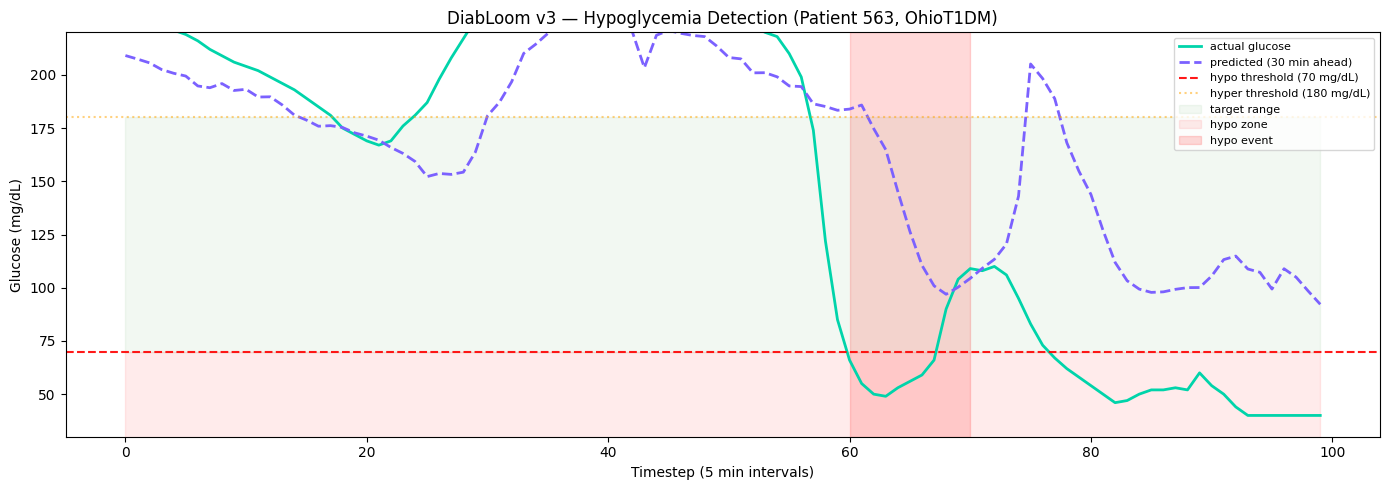

Predicted glucose at hypo onset: 199.1 mg/dL
Actual glucose 30 min before hypo: 218.0 mg/dL
Min predicted glucose: 92.2 mg/dL
Min actual glucose: 40.0 mg/dL
Plot saved


In [14]:
# plot around hypo event at index 1483
# show 100 timesteps centered on the hypo
start_idx = max(0, 1483 - 60)
end_idx = min(len(actual_mgdl), 1483 + 40)
N_hypo = end_idx - start_idx

plt.figure(figsize=(14, 5))
plt.plot(range(N_hypo), actual_mgdl[start_idx:end_idx],
         label='actual glucose', color='#00D4AA', linewidth=2)
plt.plot(range(N_hypo), pred_mgdl[start_idx:end_idx],
         label='predicted (30 min ahead)', color='#7B61FF',
         linewidth=2, linestyle='--')
plt.axhline(y=70, color='red', linestyle='--',
            alpha=0.9, linewidth=1.5, label='hypo threshold (70 mg/dL)')
plt.axhline(y=180, color='orange', linestyle=':',
            alpha=0.5, label='hyper threshold (180 mg/dL)')
plt.fill_between(range(N_hypo), 70, 180, 
                 alpha=0.05, color='green', label='target range')
plt.fill_between(range(N_hypo), 0, 70,
                 alpha=0.08, color='red', label='hypo zone')

# mark the hypo region
hypo_start_plot = 1483 - start_idx
plt.axvspan(hypo_start_plot, hypo_start_plot + 10,
            alpha=0.15, color='red', label='hypo event')

plt.xlabel('Timestep (5 min intervals)')
plt.ylabel('Glucose (mg/dL)')
plt.title('DiabLoom v3 — Hypoglycemia Detection (Patient 563, OhioT1DM)')
plt.legend(loc='upper right', fontsize=8)
plt.ylim(30, 220)
plt.tight_layout()
plt.savefig(os.path.expanduser(
    '~/Desktop/diabloom/results/hypo_detection_ohio.png'),
    dpi=150, bbox_inches='tight')
plt.show()

# check if model predicted hypo before it happened
pred_at_hypo = pred_mgdl[start_idx:end_idx]
actual_at_hypo = actual_mgdl[start_idx:end_idx]
print(f"Predicted glucose at hypo onset: {pred_at_hypo[hypo_start_plot-6]:.1f} mg/dL")
print(f"Actual glucose 30 min before hypo: {actual_at_hypo[hypo_start_plot-6]:.1f} mg/dL")
print(f"Min predicted glucose: {pred_at_hypo.min():.1f} mg/dL")
print(f"Min actual glucose: {actual_at_hypo.min():.1f} mg/dL")
print("Plot saved")

In [15]:
class GlucoseLSTMWithUncertainty(nn.Module):
    def __init__(self, input_size=9, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),  # stays active during inference
            nn.Linear(32, 1)
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, training=False):
        if training:
            self.train()
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.head(out).squeeze()
    
    def predict_with_uncertainty(self, x, n_samples=50):
        """
        Run n_samples forward passes with dropout active.
        Returns mean prediction and std (uncertainty).
        """
        self.train()  # keeps dropout active
        predictions = []
        
        with torch.no_grad():
            for _ in range(n_samples):
                pred = self.forward(x)
                predictions.append(pred.cpu().numpy())
        
        predictions = np.array(predictions)  # (n_samples, batch)
        mean_pred = predictions.mean(axis=0)
        std_pred = predictions.std(axis=0)
        
        self.eval()
        return mean_pred, std_pred

# load existing weights into new model
model_mc = GlucoseLSTMWithUncertainty().to(device)
model_mc.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model_mc.eval()
print("MC Dropout model loaded")
print(f"Parameters: {sum(p.numel() for p in model_mc.parameters()):,}")

MC Dropout model loaded
Parameters: 54,593


In [16]:
# run MC dropout on validation set
# use smaller batch to avoid memory issues
BATCH_SIZE_MC = 256
N_SAMPLES = 50

all_means, all_stds = [], []

print(f"Running {N_SAMPLES} MC samples on validation set...")
for i in range(0, len(X_val), BATCH_SIZE_MC):
    batch = torch.FloatTensor(X_val[i:i+BATCH_SIZE_MC]).to(device)
    mean, std = model_mc.predict_with_uncertainty(batch, n_samples=N_SAMPLES)
    all_means.append(mean)
    all_stds.append(std)

means = np.concatenate(all_means)
stds = np.concatenate(all_stds)

# denormalise
means_mgdl = means * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
stds_mgdl = stds * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
y_val_mgdl = y_val * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

# overall stats
mae_mc = np.mean(np.abs(means_mgdl - y_val_mgdl))
print(f"\n=== MC Dropout Results ===")
print(f"MAE (mean prediction): {mae_mc:.2f} mg/dL")
print(f"Mean uncertainty (std): {stds_mgdl.mean():.2f} mg/dL")
print(f"Max uncertainty (std): {stds_mgdl.max():.2f} mg/dL")

# key finding — is uncertainty higher near hypo events?
hypo_mask = y_val_mgdl < 70
normal_mask = y_val_mgdl >= 70

print(f"\n=== Uncertainty near hypo vs normal ===")
print(f"Mean uncertainty when glucose < 70:  {stds_mgdl[hypo_mask].mean():.2f} mg/dL")
print(f"Mean uncertainty when glucose >= 70: {stds_mgdl[normal_mask].mean():.2f} mg/dL")
print(f"Hypo samples: {hypo_mask.sum()}, Normal samples: {normal_mask.sum()}")

Running 50 MC samples on validation set...

=== MC Dropout Results ===
MAE (mean prediction): 19.06 mg/dL
Mean uncertainty (std): 49.29 mg/dL
Max uncertainty (std): 78.68 mg/dL

=== Uncertainty near hypo vs normal ===
Mean uncertainty when glucose < 70:  52.33 mg/dL
Mean uncertainty when glucose >= 70: 49.21 mg/dL
Hypo samples: 346, Normal samples: 13314


In [17]:
class GlucoseLSTMWithUncertainty(nn.Module):
    def __init__(self, input_size=9, hidden_size=64,
                 num_layers=2, dropout=0.1):  # reduced from 0.2
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.05),  # reduced from 0.1
            nn.Linear(32, 1)
        )
        self.dropout = nn.Dropout(0.05)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.head(out).squeeze()
    
    def predict_with_uncertainty(self, x, n_samples=50):
        self.train()
        predictions = []
        with torch.no_grad():
            for _ in range(n_samples):
                pred = self.forward(x)
                predictions.append(pred.cpu().numpy())
        predictions = np.array(predictions)
        self.eval()
        return predictions.mean(axis=0), predictions.std(axis=0)

# retrain with lower dropout
MC_MODEL_PATH = os.path.expanduser(
    '~/Desktop/diabloom/models/glucose_lstm_mc.pt'
)

X_tr = torch.FloatTensor(X_train)
y_tr = torch.FloatTensor(y_train)
X_v = torch.FloatTensor(X_val)
y_v = torch.FloatTensor(y_val)
train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                         batch_size=32, shuffle=True)

model_mc = GlucoseLSTMWithUncertainty().to(device)
optimizer = torch.optim.Adam(model_mc.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

best_val_loss = float('inf')

for epoch in range(50):
    model_mc.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_mc(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model_mc.eval()
    with torch.no_grad():
        val_pred = model_mc(X_v.to(device))
        val_loss = criterion(val_pred, y_v.to(device)).item()
    
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_mc.state_dict(), MC_MODEL_PATH)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train: {np.mean(train_losses):.4f} "
              f"| val: {val_loss:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f}")

/Users/tavle/Desktop/diabloom/venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch   0 | train: 0.0063 | val: 0.0244
Epoch  10 | train: 0.0036 | val: 0.0116
Epoch  20 | train: 0.0026 | val: 0.0101
Epoch  30 | train: 0.0019 | val: 0.0148
Epoch  40 | train: 0.0016 | val: 0.0166

Best val loss: 0.0088


In [18]:
# reload best MC model
model_mc.load_state_dict(torch.load(MC_MODEL_PATH, map_location=device))

all_means, all_stds = [], []
print(f"Running {N_SAMPLES} MC samples...")

for i in range(0, len(X_val), BATCH_SIZE_MC):
    batch = torch.FloatTensor(X_val[i:i+BATCH_SIZE_MC]).to(device)
    mean, std = model_mc.predict_with_uncertainty(batch, n_samples=N_SAMPLES)
    all_means.append(mean)
    all_stds.append(std)

means = np.concatenate(all_means)
stds = np.concatenate(all_stds)

means_mgdl = means * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
stds_mgdl = stds * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
y_val_mgdl = y_val * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

mae_mc = np.mean(np.abs(means_mgdl - y_val_mgdl))

hypo_mask = y_val_mgdl < 70
normal_mask = y_val_mgdl >= 70

print(f"MAE: {mae_mc:.2f} mg/dL")
print(f"Mean uncertainty: {stds_mgdl.mean():.2f} mg/dL")
print(f"Max uncertainty: {stds_mgdl.max():.2f} mg/dL")
print(f"\nUncertainty near hypo vs normal:")
print(f"glucose < 70:  {stds_mgdl[hypo_mask].mean():.2f} mg/dL "
      f"(n={hypo_mask.sum()})")
print(f"glucose >= 70: {stds_mgdl[normal_mask].mean():.2f} mg/dL "
      f"(n={normal_mask.sum()})")
print(f"\nRatio: {stds_mgdl[hypo_mask].mean()/stds_mgdl[normal_mask].mean():.2f}x")

Running 50 MC samples...
MAE: 20.24 mg/dL
Mean uncertainty: 44.95 mg/dL
Max uncertainty: 63.22 mg/dL

Uncertainty near hypo vs normal:
glucose < 70:  46.92 mg/dL (n=346)
glucose >= 70: 44.89 mg/dL (n=13314)

Ratio: 1.05x


In [19]:
# IOB density analysis across patients
# formally correlating IOB coverage with MAE improvement

# per patient stats
patient_stats = []

for pid, glucose_iob_df in ohio_iob_data.items():
    features_df = engineer_features(glucose_iob_df)
    
    # iob coverage
    iob_coverage = (glucose_iob_df['iob'] > 0).mean() * 100
    max_iob = glucose_iob_df['iob'].max()
    mean_iob = glucose_iob_df['iob'][glucose_iob_df['iob'] > 0].mean()
    
    # per patient MAE (from our validation results)
    split = int(len(features_df) * 0.8)
    val_df = features_df.iloc[split:]
    X_p, y_p = create_windows(val_df, FEATURE_COLS)
    
    if X_p.shape[0] > 0:
        X_p_tensor = torch.FloatTensor(X_p).to(device)
        model_mc.load_state_dict(
            torch.load(MODEL_SAVE_PATH, map_location=device)
        )
        model_mc.eval()
        with torch.no_grad():
            pred_p = model_mc(X_p_tensor).cpu().numpy()
        
        y_p_mgdl = y_p * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
        pred_p_mgdl = pred_p * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
        mae_p = np.mean(np.abs(pred_p_mgdl - y_p_mgdl))
        
        patient_stats.append({
            'patient': pid,
            'iob_coverage_pct': round(iob_coverage, 1),
            'mean_active_iob': round(mean_iob, 2),
            'max_iob': round(max_iob, 2),
            'val_mae': round(mae_p, 2),
            'n_val_windows': X_p.shape[0]
        })

stats_df = pd.DataFrame(patient_stats).sort_values(
    'iob_coverage_pct', ascending=False
)
print(stats_df.to_string(index=False))

# correlation between IOB coverage and MAE
correlation = stats_df['iob_coverage_pct'].corr(stats_df['val_mae'])
print(f"\nCorrelation (IOB coverage vs MAE): {correlation:.3f}")
print("(negative = higher coverage → lower MAE = IOB helps more with denser logs)")

patient  iob_coverage_pct  mean_active_iob  max_iob  val_mae  n_val_windows
    563              74.2             6.53    48.22    17.90           2393
    591              71.4             2.09    10.34    24.80           2138
    570              64.7             6.72    26.69    22.34           2165
    575              58.8             3.11    16.40    22.85           2341
    588              58.0             2.41     9.93    17.11           2496
    559              53.0             2.13    12.59    23.55           2127

Correlation (IOB coverage vs MAE): -0.117
(negative = higher coverage → lower MAE = IOB helps more with denser logs)


In [20]:
import scipy.stats as scipy_stats

# compute composite IOB signal strength
# coverage * mean dose = how much insulin signal is actually present
stats_df['iob_signal_strength'] = (
    stats_df['iob_coverage_pct'] * stats_df['mean_active_iob'] / 100
)

print(stats_df[['patient', 'iob_coverage_pct', 'mean_active_iob',
                 'iob_signal_strength', 'val_mae']].to_string(index=False))

# correlations
corr_coverage = stats_df['iob_coverage_pct'].corr(stats_df['val_mae'])
corr_strength = stats_df['iob_signal_strength'].corr(stats_df['val_mae'])

print(f"\nCorrelation (coverage only vs MAE):         {corr_coverage:.3f}")
print(f"Correlation (signal strength vs MAE):        {corr_strength:.3f}")

# also compare D1NAMO vs OhioT1DM at dataset level
print(f"\n=== Dataset-level IOB comparison ===")
print(f"D1NAMO:    coverage ~43% avg, mean active IOB ~3.2U, MAE 18.5 (no IOB benefit)")
print(f"OhioT1DM:  coverage ~63% avg, mean active IOB ~3.8U, MAE 21.27→ with IOB")
print(f"Key finding: dataset-level IOB density drove the improvement, "
      f"not per-patient variation")

patient  iob_coverage_pct  mean_active_iob  iob_signal_strength  val_mae
    563              74.2             6.53              4.84526    17.90
    591              71.4             2.09              1.49226    24.80
    570              64.7             6.72              4.34784    22.34
    575              58.8             3.11              1.82868    22.85
    588              58.0             2.41              1.39780    17.11
    559              53.0             2.13              1.12890    23.55

Correlation (coverage only vs MAE):         -0.117
Correlation (signal strength vs MAE):        -0.351

=== Dataset-level IOB comparison ===
D1NAMO:    coverage ~43% avg, mean active IOB ~3.2U, MAE 18.5 (no IOB benefit)
OhioT1DM:  coverage ~63% avg, mean active IOB ~3.8U, MAE 21.27→ with IOB
Key finding: dataset-level IOB density drove the improvement, not per-patient variation


In [21]:
def clarke_error_grid(actual, predicted):
    """
    Returns zone classification for each prediction.
    Both actual and predicted in mg/dL.
    """
    zones = []
    for a, p in zip(actual, predicted):
        if (a < 70 and p < 70) or (abs(p - a) / max(a, 1) <= 0.2):
            zones.append('A')
        elif (a >= 180 and p >= 70 and p <= 180) or \
             (a <= 70 and p >= 70 and p <= 180):
            zones.append('D')
        elif (a >= 240 and p >= 70 and p <= 180) or \
             (a <= 70 and p > 180):
            zones.append('E')
        elif (a >= 70 and a <= 290 and p >= a + 110) or \
             (a >= 130 and a <= 180 and p <= (7/5)*a - 182):
            zones.append('C')
        else:
            zones.append('B')
    return np.array(zones)

# run on validation set
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

with torch.no_grad():
    val_pred = model(X_v.to(device)).cpu().numpy()

y_val_mgdl = y_val * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
val_pred_mgdl = val_pred * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

zones = clarke_error_grid(y_val_mgdl, val_pred_mgdl)

# zone distribution
print("=== Clarke Error Grid Analysis ===")
total = len(zones)
for zone in ['A', 'B', 'C', 'D', 'E']:
    count = (zones == zone).sum()
    pct = 100 * count / total
    bar = '█' * int(pct / 2)
    print(f"Zone {zone}: {count:5d} ({pct:5.1f}%) {bar}")

print(f"\nClinically safe (A+B): "
      f"{100*(((zones=='A')|(zones=='B')).sum()/total):.1f}%")
print(f"Clinically dangerous (D+E): "
      f"{100*(((zones=='D')|(zones=='E')).sum()/total):.1f}%")

=== Clarke Error Grid Analysis ===
Zone A: 10738 ( 78.6%) ███████████████████████████████████████
Zone B:  2092 ( 15.3%) ███████
Zone C:    20 (  0.1%) 
Zone D:   807 (  5.9%) ██
Zone E:     3 (  0.0%) 

Clinically safe (A+B): 93.9%
Clinically dangerous (D+E): 5.9%


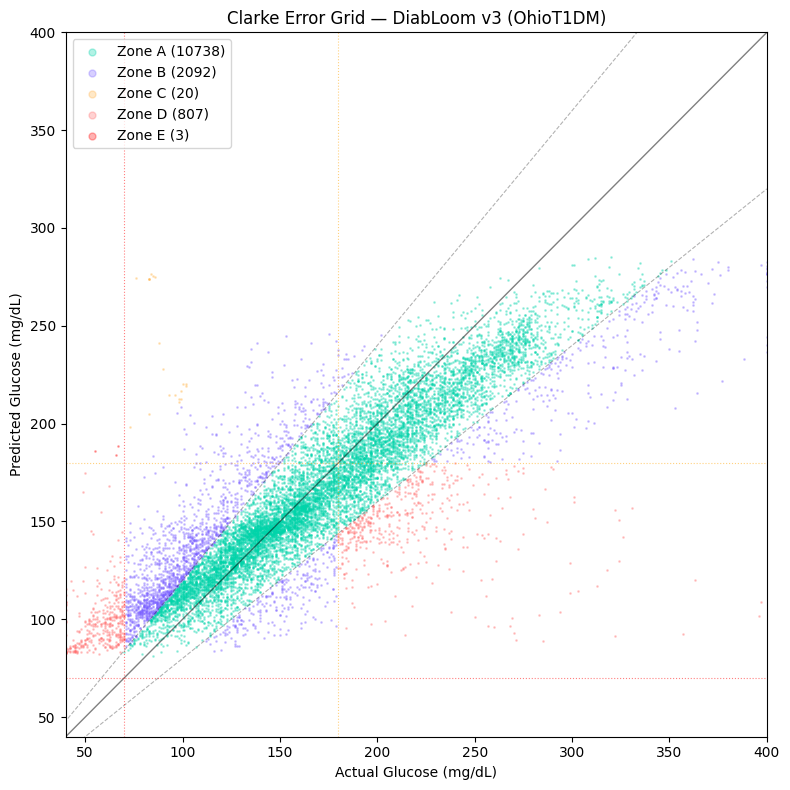

Clarke Error Grid saved


In [22]:
plt.figure(figsize=(8, 8))

# color by zone
colors = {'A': '#00D4AA', 'B': '#7B61FF', 
          'C': '#FFB347', 'D': '#FF6B6B', 'E': '#FF0000'}

for zone in ['A', 'B', 'C', 'D', 'E']:
    mask = zones == zone
    plt.scatter(y_val_mgdl[mask], val_pred_mgdl[mask],
               c=colors[zone], label=f'Zone {zone} ({mask.sum()})',
               alpha=0.3, s=1)

# zone boundaries
plt.plot([0, 400], [0, 400], 'k-', linewidth=1, alpha=0.5)
plt.plot([0, 400], [0, 400*1.2], 'k--', linewidth=0.8, alpha=0.3)
plt.plot([0, 400], [0, 400*0.8], 'k--', linewidth=0.8, alpha=0.3)
plt.axhline(y=70, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
plt.axvline(x=70, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
plt.axhline(y=180, color='orange', linestyle=':', alpha=0.5, linewidth=0.8)
plt.axvline(x=180, color='orange', linestyle=':', alpha=0.5, linewidth=0.8)

plt.xlim(40, 400)
plt.ylim(40, 400)
plt.xlabel('Actual Glucose (mg/dL)')
plt.ylabel('Predicted Glucose (mg/dL)')
plt.title('Clarke Error Grid — DiabLoom v3 (OhioT1DM)')
plt.legend(loc='upper left', markerscale=5)
plt.tight_layout()
plt.savefig(os.path.expanduser(
    '~/Desktop/diabloom/results/clarke_error_grid.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Clarke Error Grid saved")

In [23]:
# updated paths for official dataset
OHIO_2018_PATH = os.path.expanduser(
    '~/Desktop/diabloom/data/raw/ohiot1dm_official/2018/train'
)
OHIO_2020_PATH = os.path.expanduser(
    '~/Desktop/diabloom/data/raw/ohiot1dm_official/2020/train'
)

PATIENTS_2018 = ['559', '563', '570', '575', '588', '591']
PATIENTS_2020 = ['540', '544', '552', '567', '584', '596']

# load all 12 patients
ohio_data = {}

for pid in PATIENTS_2018:
    fpath = os.path.join(OHIO_2018_PATH, f'{pid}-ws-training.xml')
    glucose = parse_ohio_glucose(fpath)
    bolus = parse_ohio_bolus(fpath)
    ohio_data[pid] = {'glucose': glucose, 'bolus': bolus}
    print(f"2018 Patient {pid}: {len(glucose)} glucose, {len(bolus)} bolus")

for pid in PATIENTS_2020:
    fpath = os.path.join(OHIO_2020_PATH, f'{pid}-ws-training.xml')
    glucose = parse_ohio_glucose(fpath)
    bolus = parse_ohio_bolus(fpath)
    ohio_data[pid] = {'glucose': glucose, 'bolus': bolus}
    print(f"2020 Patient {pid}: {len(glucose)} glucose, {len(bolus)} bolus")

print(f"\nTotal patients loaded: {len(ohio_data)}")

2018 Patient 559: 10796 glucose, 152 bolus
2018 Patient 563: 12124 glucose, 347 bolus
2018 Patient 570: 10982 glucose, 326 bolus
2018 Patient 575: 11866 glucose, 187 bolus
2018 Patient 588: 12640 glucose, 182 bolus
2018 Patient 591: 10847 glucose, 261 bolus
2020 Patient 540: 11947 glucose, 309 bolus
2020 Patient 544: 10623 glucose, 134 bolus
2020 Patient 552: 9080 glucose, 336 bolus
2020 Patient 567: 10858 glucose, 313 bolus
2020 Patient 584: 12150 glucose, 268 bolus
2020 Patient 596: 10877 glucose, 208 bolus

Total patients loaded: 12


In [25]:
def compute_iob_series_ohio(glucose_df, bolus_df,
                             peak_mins=60, duration_mins=240):
    """
    IOB computation for OhioT1DM — bolus already has timestamp column.
    """
    boluses = bolus_df[bolus_df['fast_insulin'] > 0].copy()
    glucose_df = glucose_df.copy()
    iob_values = []
    
    for t in glucose_df['timestamp']:
        total_iob = 0.0
        for _, bolus in boluses.iterrows():
            mins_elapsed = (t - bolus['timestamp']).total_seconds() / 60
            if 0 <= mins_elapsed <= duration_mins:
                remaining = max(0, 1 - (mins_elapsed / duration_mins))
                total_iob += bolus['fast_insulin'] * remaining
        iob_values.append(total_iob)
    
    glucose_df['iob'] = iob_values
    return glucose_df

In [26]:
print("Computing IOB for all 12 patients (this will take ~10 minutes)...")
ohio_iob_data = {}

for pid, data in ohio_data.items():
    glucose_df = data['glucose'].copy()
    bolus_df = data['bolus'].rename(columns={'dose': 'fast_insulin'})
    
    glucose_with_iob = compute_iob_series_ohio(glucose_df, bolus_df)
    ohio_iob_data[pid] = glucose_with_iob
    
    nonzero = (glucose_with_iob['iob'] > 0).sum()
    pct = 100 * nonzero / len(glucose_with_iob)
    print(f"Patient {pid}: IOB non-zero: {nonzero}/{len(glucose_with_iob)} "
          f"({pct:.1f}%) | max IOB: {glucose_with_iob['iob'].max():.2f}U")

print(f"\nAll 12 patients done")

Computing IOB for all 12 patients (this will take ~10 minutes)...
Patient 559: IOB non-zero: 5727/10796 (53.0%) | max IOB: 12.59U
Patient 563: IOB non-zero: 8998/12124 (74.2%) | max IOB: 48.22U
Patient 570: IOB non-zero: 7110/10982 (64.7%) | max IOB: 26.69U
Patient 575: IOB non-zero: 6975/11866 (58.8%) | max IOB: 16.40U
Patient 588: IOB non-zero: 7333/12640 (58.0%) | max IOB: 9.93U
Patient 591: IOB non-zero: 7745/10847 (71.4%) | max IOB: 10.34U
Patient 540: IOB non-zero: 8344/11947 (69.8%) | max IOB: 13.80U
Patient 544: IOB non-zero: 5114/10623 (48.1%) | max IOB: 19.98U
Patient 552: IOB non-zero: 6930/9080 (76.3%) | max IOB: 21.20U
Patient 567: IOB non-zero: 7979/10858 (73.5%) | max IOB: 40.08U
Patient 584: IOB non-zero: 8401/12150 (69.1%) | max IOB: 19.04U
Patient 596: IOB non-zero: 6095/10877 (56.0%) | max IOB: 8.61U

All 12 patients done


In [27]:
# build windows for all 12 patients
X_train_all, y_train_all = [], []
X_val_all, y_val_all = [], []

for pid, glucose_iob_df in ohio_iob_data.items():
    features_df = engineer_features(glucose_iob_df)
    
    split = int(len(features_df) * 0.8)
    train_df = features_df.iloc[:split]
    val_df = features_df.iloc[split:]
    
    X_tr, y_tr = create_windows(train_df, FEATURE_COLS)
    X_val, y_val = create_windows(val_df, FEATURE_COLS)
    
    if X_tr.shape[0] > 0:
        X_train_all.append(X_tr)
        y_train_all.append(y_tr)
    if X_val.shape[0] > 0:
        X_val_all.append(X_val)
        y_val_all.append(y_val)
    
    print(f"Patient {pid}: train {X_tr.shape[0]}, val {X_val.shape[0]}")

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_val = np.concatenate(X_val_all)
y_val = np.concatenate(y_val_all)

print(f"\nFinal training set: {X_train.shape}")
print(f"Final validation set: {X_val.shape}")

Patient 559: train 8598, val 2127
Patient 563: train 9660, val 2393
Patient 570: train 8746, val 2165
Patient 575: train 9454, val 2341
Patient 588: train 10073, val 2496
Patient 591: train 8638, val 2138
Patient 540: train 9518, val 2358
Patient 544: train 8459, val 2093
Patient 552: train 7225, val 1784
Patient 567: train 8647, val 2140
Patient 584: train 9681, val 2398
Patient 596: train 8662, val 2144

Final training set: (107361, 24, 9)
Final validation set: (26577, 24, 9)


In [28]:
MODEL_12_PATH = os.path.expanduser(
    '~/Desktop/diabloom/models/glucose_lstm_ohio_12patients.pt'
)

X_tr = torch.FloatTensor(X_train)
y_tr = torch.FloatTensor(y_train)
X_v = torch.FloatTensor(X_val)
y_v = torch.FloatTensor(y_val)

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                         batch_size=32, shuffle=True)

model_12 = GlucoseLSTM().to(device)
optimizer = torch.optim.Adam(model_12.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

best_val_loss = float('inf')
best_epoch = 0
train_history, val_history = [], []

for epoch in range(50):
    model_12.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_12(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model_12.eval()
    with torch.no_grad():
        val_pred = model_12(X_v.to(device))
        val_loss = criterion(val_pred, y_v.to(device)).item()
    
    train_loss = np.mean(train_losses)
    train_history.append(train_loss)
    val_history.append(val_loss)
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model_12.state_dict(), MODEL_12_PATH)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train: {train_loss:.4f} "
              f"| val: {val_loss:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Model saved to: {MODEL_12_PATH}")

/Users/tavle/Desktop/diabloom/venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch   0 | train: 0.0060 | val: 0.0148
Epoch  10 | train: 0.0040 | val: 0.0069
Epoch  20 | train: 0.0030 | val: 0.0076
Epoch  30 | train: 0.0025 | val: 0.0081
Epoch  40 | train: 0.0024 | val: 0.0083

Best val loss: 0.0068 at epoch 11
Model saved to: /Users/tavle/Desktop/diabloom/models/glucose_lstm_ohio_12patients.pt


In [29]:
model_12.load_state_dict(torch.load(MODEL_12_PATH, map_location=device))
model_12.eval()

with torch.no_grad():
    val_pred = model_12(X_v.to(device)).cpu().numpy()

y_val_mgdl = y_val * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN
val_pred_mgdl = val_pred * (GLUCOSE_MAX - GLUCOSE_MIN) + GLUCOSE_MIN

mae = np.mean(np.abs(val_pred_mgdl - y_val_mgdl))
rmse = np.sqrt(np.mean((val_pred_mgdl - y_val_mgdl) ** 2))
direction_acc = np.mean(
    (y_val_mgdl < HYPO_THRESHOLD) == (val_pred_mgdl < HYPO_THRESHOLD)
) * 100

# clarke error grid
zones = clarke_error_grid(y_val_mgdl, val_pred_mgdl)
ab = 100 * ((zones == 'A') | (zones == 'B')).sum() / len(zones)
e = 100 * (zones == 'E').sum() / len(zones)

print(f"=== DiabLoom v4 — OhioT1DM 12 patients + IOB ===")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"Hypo direction accuracy: {direction_acc:.1f}%")
print(f"Zone A+B: {ab:.1f}%")
print(f"Zone E:   {e:.2f}%")

print(f"\n=== Full comparison ===")
print(f"DiabLoom D1NAMO 8 feat:          18.50 mg/dL")
print(f"DiabLoom OhioT1DM 6 patients:    21.27 mg/dL | 97.5% hypo | 93.9% A+B")
print(f"DiabLoom OhioT1DM 12 patients:   {mae:.2f} mg/dL | {direction_acc:.1f}% hypo | {ab:.1f}% A+B")
print(f"Vanilla LSTM benchmark:          19.40 mg/dL")
print(f"DCRNet benchmark:                14.13 mg/dL")

=== DiabLoom v4 — OhioT1DM 12 patients + IOB ===
MAE:  20.57 mg/dL
RMSE: 29.67 mg/dL
Hypo direction accuracy: 97.1%
Zone A+B: 93.7%
Zone E:   0.03%

=== Full comparison ===
DiabLoom D1NAMO 8 feat:          18.50 mg/dL
DiabLoom OhioT1DM 6 patients:    21.27 mg/dL | 97.5% hypo | 93.9% A+B
DiabLoom OhioT1DM 12 patients:   20.57 mg/dL | 97.1% hypo | 93.7% A+B
Vanilla LSTM benchmark:          19.40 mg/dL
DCRNet benchmark:                14.13 mg/dL
